# QS-Net (PyTorch Version): Tune $\lambda_1$, $\lambda_2$ Sensitivity
## CICIoT2023 | 0.5% Training (Weighted) | Batch Size 64 | 10 Epochs | LR 0.05
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
# UNCOMMENT FOR KAGGLE
# %pip install -q pennylane pyarrow fastparquet

In [2]:
import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import sys
import json
from pathlib import Path
from itertools import product
import time
from collections import Counter

In [3]:
# UNCOMMENT FOR KAGGLE
# NOTEBOOK_NAME = "tune-lambdas-ciciot"
# DATA_ROOT = Path("/kaggle/input/datasets/lawunnannda/quantum-sentinel-iot-v1-0")
# dataset = "CICIoT2023"
# data_path = f"{DATA_ROOT}/{dataset}/quantum"
# target_col = "label_multiclass"
# split_prefix = "q8"

# SCRIPTS_ROOT = Path("/kaggle/input/datasets/lawunnannda/quantum-sentinel-scripts")
# sys.path.insert(0, str(SCRIPTS_ROOT))

# log_dir = "/kaggle/working/logs"
# Path(f"{log_dir}").mkdir(parents=True, exist_ok=True)

In [4]:
from scripts.constants import DEFAULT_NOISE_RATE
from scripts.data import load_split, stratified_head
from scripts.circuit import build_forward_circuit, create_quantum_device, initialize_weights
from scripts.prototypes import PrototypeBank
from scripts.loss import maqt_loss, gradient_variance
from scripts.logging import write_history_log
from scripts.inference import predict_labels
from scripts.utils import to_np_x, to_torch_x

In [5]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: CICIoT2023

In [6]:
NOTEBOOK_NAME = "tune-lambdas-ciciot2023"
dataset = "CICIoT2023"
data_path = f"data/{dataset}/quantum"
target_col = "label_multiclass"
split_prefix = "q8"

In [7]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [8]:
print(df["label_multiclass"].unique())
print()
print(df["label_family"].unique())

<ArrowStringArray>
[       'DDoS-RSTFINFlood',           'BenignTraffic',
         'DDoS-ICMP_Flood',          'DDoS-TCP_Flood',
 'DDoS-SynonymousIP_Flood',          'DDoS-SlowLoris',
       'DDoS-PSHACK_Flood',           'DoS-TCP_Flood',
          'DDoS-UDP_Flood',           'DoS-UDP_Flood',
          'DoS-HTTP_Flood',          'DDoS-SYN_Flood',
           'DoS-SYN_Flood',        'MITM-ArpSpoofing',
    'DictionaryBruteForce',            'DNS_Spoofing',
  'DDoS-UDP_Fragmentation',          'Recon-PortScan',
       'VulnerabilityScan',                     'XSS',
         'DDoS-HTTP_Flood', 'DDoS-ICMP_Fragmentation',
  'DDoS-ACK_Fragmentation',     'Recon-HostDiscovery',
            'Recon-OSScan',        'BrowserHijacking',
         'Recon-PingSweep',            'SqlInjection',
        'Backdoor_Malware',        'CommandInjection',
        'Uploading_Attack']
Length: 31, dtype: str

<ArrowStringArray>
[                       'ddos',                      'benign',
                      

In [9]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [10]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Backdoor_Malware',
 'BenignTraffic',
 'BrowserHijacking',
 'CommandInjection',
 'DDoS-ACK_Fragmentation',
 'DDoS-HTTP_Flood',
 'DDoS-ICMP_Flood',
 'DDoS-ICMP_Fragmentation',
 'DDoS-PSHACK_Flood',
 'DDoS-RSTFINFlood',
 'DDoS-SYN_Flood',
 'DDoS-SlowLoris',
 'DDoS-SynonymousIP_Flood',
 'DDoS-TCP_Flood',
 'DDoS-UDP_Flood',
 'DDoS-UDP_Fragmentation',
 'DNS_Spoofing',
 'DictionaryBruteForce',
 'DoS-HTTP_Flood',
 'DoS-SYN_Flood',
 'DoS-TCP_Flood',
 'DoS-UDP_Flood',
 'MITM-ArpSpoofing',
 'Recon-HostDiscovery',
 'Recon-OSScan',
 'Recon-PingSweep',
 'Recon-PortScan',
 'SqlInjection',
 'Uploading_Attack',
 'VulnerabilityScan',
 'XSS']

In [11]:
# load all data
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)
X_val_full, y_val_full = load_split(data_path, f"{split_prefix}_val", target_col, class_names)

In [12]:
# check shape
[X_train_full.shape, y_train_full.shape], [X_val_full.shape, y_val_full.shape]

([(132166, 8), (132166,)], [(18883, 8), (18883,)])

## Class Weighting, Data Subset

- Rebalance **training only** (tempered class-weighted CE).
- Keep **val / calibration / test** unchanged (natural distribution).
- Do **not** use hard equal-count undersampling of every class.
- Do **not** use SMOTE after quantum encoding.
- Never train/tune on zero-day.

In [13]:
percentage = 0.5 / 100 # 0.5% of original data

In [14]:
# take subset
X_train, y_train = stratified_head(X_train_full, y_train_full, round(percentage * X_train_full.shape[0]), seed=42)
X_val, y_val = stratified_head(X_val_full, y_val_full, round(percentage * X_val_full.shape[0]), seed=42)

In [15]:
# recompute tempered weights on the actual training y
y_np = to_np_x(y_train).astype(int)
counts = Counter(y_np.tolist())
raw = {c: 1.0 / (counts[c] ** 0.5) for c in counts}

# normalize to mean 1, then clip
mean_w = sum(raw.values()) / len(raw)
class_weight = {c: min(max(raw[c] / mean_w, 0.25), 4.0) for c in raw}

weight_tensor = torch.tensor(
    [class_weight.get(i, 1.0) for i in range(len(class_names))],
    dtype=torch.float32,
)

print("train class counts:", dict(sorted(counts.items())))
print()
print("tempered class weights:", {class_names[c]: round(class_weight[c], 3) for c in sorted(class_weight)})

train class counts: {1: 16, 2: 1, 3: 1, 4: 4, 5: 2, 6: 106, 7: 7, 8: 60, 9: 59, 10: 60, 11: 2, 12: 53, 13: 66, 14: 79, 15: 4, 16: 3, 17: 1, 18: 6, 19: 30, 20: 39, 21: 49, 22: 5, 23: 2, 24: 1, 26: 1, 27: 1, 29: 3}

tempered class weights: {'BenignTraffic': 0.515, 'BrowserHijacking': 2.061, 'CommandInjection': 2.061, 'DDoS-ACK_Fragmentation': 1.03, 'DDoS-HTTP_Flood': 1.457, 'DDoS-ICMP_Flood': 0.25, 'DDoS-ICMP_Fragmentation': 0.779, 'DDoS-PSHACK_Flood': 0.266, 'DDoS-RSTFINFlood': 0.268, 'DDoS-SYN_Flood': 0.266, 'DDoS-SlowLoris': 1.457, 'DDoS-SynonymousIP_Flood': 0.283, 'DDoS-TCP_Flood': 0.254, 'DDoS-UDP_Flood': 0.25, 'DDoS-UDP_Fragmentation': 1.03, 'DNS_Spoofing': 1.19, 'DictionaryBruteForce': 2.061, 'DoS-HTTP_Flood': 0.841, 'DoS-SYN_Flood': 0.376, 'DoS-TCP_Flood': 0.33, 'DoS-UDP_Flood': 0.294, 'MITM-ArpSpoofing': 0.921, 'Recon-HostDiscovery': 1.457, 'Recon-OSScan': 2.061, 'Recon-PortScan': 2.061, 'SqlInjection': 2.061, 'VulnerabilityScan': 1.19}


In [16]:
# check shape
[X_train.shape, y_train.shape], [X_val.shape, y_val.shape]

([(661, 8), (661,)], [(94, 8), (94,)])

## EDA (After Class-Weighting)

In [17]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"classes: {class_names}")
print(f"\nnumber of classes: {num_classes}")
print(f"\nnumber of qubits: {num_qubits}")

classes: ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']

number of classes: 31

number of qubits: 8


In [18]:
# initialize devices
dev = qp.device("default.mixed", wires=num_qubits)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
# convert data type and move to device
X_train = to_torch_x(X_train, device)
y_train = to_torch_x(y_train, device).long()

# move weight tensor to device
weight_tensor = weight_tensor.to(device)

# verify
X_train[:5], y_train[:5], weight_tensor

(tensor([[2.5766e-01, 2.0335e-02, 1.5794e-01, 3.6899e-01, 1.7004e-01, 1.2563e+00,
          1.7874e-01, 3.1416e+00],
         [0.0000e+00, 0.0000e+00, 6.6532e-01, 0.0000e+00, 7.7912e-01, 1.5550e+00,
          9.6771e-01, 1.2385e+00],
         [0.0000e+00, 6.5635e-03, 8.5190e-02, 0.0000e+00, 9.8319e-02, 1.0230e+00,
          1.2391e-01, 1.2385e+00],
         [0.0000e+00, 5.0852e-01, 1.2289e-01, 0.0000e+00, 1.4197e-01, 1.0578e+00,
          1.7874e-01, 3.1416e+00],
         [9.0682e-02, 3.9140e-04, 6.9747e-01, 1.1865e+00, 7.6320e-01, 1.5372e+00,
          6.0999e-01, 3.1416e+00]], device='cuda:0'),
 tensor([23, 21, 14, 20, 10], device='cuda:0'),
 tensor([1.0000, 0.5151, 2.0605, 2.0605, 1.0303, 1.4570, 0.2500, 0.7788, 0.2660,
         0.2683, 0.2660, 1.4570, 0.2830, 0.2536, 0.2500, 1.0303, 1.1896, 2.0605,
         0.8412, 0.3762, 0.3299, 0.2944, 0.9215, 1.4570, 2.0605, 1.0000, 2.0605,
         2.0605, 1.0000, 1.1896, 1.0000], device='cuda:0'))

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

In [20]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [21]:
# initialize deviceSize
dev = create_quantum_device(num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

# no global theta and classifier head initalization
## each lambdas pair has its own theta and classifier head

## Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [22]:
# # smoke test
# lambda1_grid = [0.0, 0.1]
# lambda2_grid = [0.0, 0.1]

# real test
lambda1_grid = [0.0, 0.33, 0.66, 1]
lambda2_grid = [0.0, 0.33, 0.66, 1]

lambda_grid = list(product(lambda1_grid, lambda2_grid))
print(f"grid size: {len(lambda_grid)} runs")
for a, b in lambda_grid:
    print(f"  λ1={a}, λ2={b}")

grid size: 16 runs
  λ1=0.0, λ2=0.0
  λ1=0.0, λ2=0.33
  λ1=0.0, λ2=0.66
  λ1=0.0, λ2=1
  λ1=0.33, λ2=0.0
  λ1=0.33, λ2=0.33
  λ1=0.33, λ2=0.66
  λ1=0.33, λ2=1
  λ1=0.66, λ2=0.0
  λ1=0.66, λ2=0.33
  λ1=0.66, λ2=0.66
  λ1=0.66, λ2=1
  λ1=1, λ2=0.0
  λ1=1, λ2=0.33
  λ1=1, λ2=0.66
  λ1=1, λ2=1


In [23]:
seed = 42
epochs = 10
batch_size = 64
lr = 0.05
barren_plateau_var = 1e-6
COMPUTE_GRAD_VAR = False
IMBALANCE_MODE = "class_weighted_ce"

In [24]:
def train_one_lambda(lambda1, lambda2):
    """
    Fixed-epoch MAQT run returning history and summary metrics.
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # initialize weights
    theta = initialize_weights(num_layers, num_qubits, device)

    # define classifier head
    classifier_head = nn.Linear(num_qubits, num_classes).to(device)

    # define loss function
    if IMBALANCE_MODE == "class_weighted_ce":
        ce_loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
    else:
        ce_loss_fn = nn.CrossEntropyLoss()

    # define optimizer
    optimizer = torch.optim.Adam(list([theta]) + list(classifier_head.parameters()), lr=lr)

    # define prototype bank
    prototype_bank = PrototypeBank(range(num_classes))

    history = {
        "loss": [], "l_ce": [], "l_intra": [], "l_inter": [],
        "grad_var": [], "barren_plateau": [],
        "val_macro_f1": [], "epoch_sec": [],
    }

    num_batches = (len(X_train) + batch_size - 1) // batch_size
    t0 = time.perf_counter()

    for epoch in range(epochs):
        epoch_t0 = time.perf_counter()
        prototype_bank.reset()
        perm = torch.randperm(len(X_train), device=device)

        epoch_grad_vars = []
        epoch_loss, epoch_ce, epoch_intra, epoch_inter = [], [], [], []

        for batch_idx, start in enumerate(range(0, len(perm), batch_size)):
            idx = perm[start : start + batch_size]
            X_batch, y_batch = X_train[idx], y_train[idx]

            for x, label in zip(X_batch, y_batch):
                _, rho_x = forward_circuit(x, theta)
                prototype_bank.update(int(label.item()), rho_x)
            batch_prototypes = prototype_bank.means()

            loss, L_CE, L_intra, L_inter = maqt_loss(
                theta, classifier_head, ce_loss_fn,
                X_batch, y_batch, batch_prototypes, forward_circuit,
                lambda1=lambda1, lambda2=lambda2, device=device,
            )

            optimizer.zero_grad()
            loss.backward()

            if COMPUTE_GRAD_VAR:
                gvar, _ = gradient_variance(
                    theta, classifier_head, ce_loss_fn,
                    X_batch, y_batch, batch_prototypes, forward_circuit,
                    lambda1=lambda1, lambda2=lambda2, device=device,
                )
                epoch_grad_vars.append(gvar)

            optimizer.step()

            epoch_loss.append(float(loss.item()))
            epoch_ce.append(float(L_CE.item()))
            epoch_intra.append(float(L_intra.item()))
            epoch_inter.append(float(L_inter.item()))

        mean_gvar = float(np.mean(epoch_grad_vars)) if epoch_grad_vars else 0.0
        plateau = mean_gvar < barren_plateau_var

        history["loss"].append(float(np.mean(epoch_loss)))
        history["l_ce"].append(float(np.mean(epoch_ce)))
        history["l_intra"].append(float(np.mean(epoch_intra)))
        history["l_inter"].append(float(np.mean(epoch_inter)))
        history["grad_var"].append(mean_gvar)
        history["barren_plateau"].append(bool(plateau))

        y_true, y_pred = predict_labels(
            X_val, y_val, theta, classifier_head, forward_circuit, device
        )
        val_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
        history["val_macro_f1"].append(val_f1)
        history["epoch_sec"].append(time.perf_counter() - epoch_t0)

        print(
            f"[λ1={lambda1}, λ2={lambda2}] "
            f"epoch {epoch+1:02d}/{epochs} | "
            f"loss={history['loss'][-1]:.4f} | "
            f"l_intra={history['l_intra'][-1]:.4f} | "
            f"l_inter={history['l_inter'][-1]:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"grad_var={mean_gvar:.2e} | barren={plateau}"
        )

    summary = {
        "lambda1": float(lambda1),
        "lambda2": float(lambda2),
        "epochs": epochs,
        "train_sec": float(time.perf_counter() - t0),
        "val_macro_f1_last": history["val_macro_f1"][-1],
        "val_macro_f1_best": float(max(history["val_macro_f1"])),
        "l_intra_last": history["l_intra"][-1],
        "l_inter_last": history["l_inter"][-1],
        "grad_var_last": history["grad_var"][-1],
        "grad_var_min": float(min(history["grad_var"])) if history["grad_var"] else None,
        "barren_plateau_any": bool(any(history["barren_plateau"])),
        "barren_plateau_ok": not bool(any(history["barren_plateau"])),  # True if never collapsed
    }
    return history, summary

In [25]:
sensitivity_rows = []
histories = {}

for lambda1, lambda2 in lambda_grid:
    print("=" * 72)
    print(f"training λ1={lambda1}, λ2={lambda2}")
    hist, summary = train_one_lambda(lambda1, lambda2)
    histories[(lambda1, lambda2)] = hist
    sensitivity_rows.append(summary)

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(
    ["val_macro_f1_best", "l_intra_last"], ascending=[False, True]
)
sensitivity_df

training λ1=0.0, λ2=0.0
[λ1=0.0, λ2=0.0] epoch 01/10 | loss=2.8796 | l_intra=0.2018 | l_inter=-0.8296 | val_f1=0.0479 | grad_var=0.00e+00 | barren=True
[λ1=0.0, λ2=0.0] epoch 02/10 | loss=2.2162 | l_intra=0.2057 | l_inter=-0.8144 | val_f1=0.0469 | grad_var=0.00e+00 | barren=True
[λ1=0.0, λ2=0.0] epoch 03/10 | loss=2.0890 | l_intra=0.1954 | l_inter=-0.8256 | val_f1=0.0542 | grad_var=0.00e+00 | barren=True
[λ1=0.0, λ2=0.0] epoch 04/10 | loss=1.9894 | l_intra=0.2080 | l_inter=-0.8431 | val_f1=0.0364 | grad_var=0.00e+00 | barren=True
[λ1=0.0, λ2=0.0] epoch 05/10 | loss=1.9294 | l_intra=0.2002 | l_inter=-0.8056 | val_f1=0.1040 | grad_var=0.00e+00 | barren=True
[λ1=0.0, λ2=0.0] epoch 06/10 | loss=1.9010 | l_intra=0.1807 | l_inter=-0.8126 | val_f1=0.1003 | grad_var=0.00e+00 | barren=True
[λ1=0.0, λ2=0.0] epoch 07/10 | loss=1.8738 | l_intra=0.1884 | l_inter=-0.8144 | val_f1=0.1537 | grad_var=0.00e+00 | barren=True
[λ1=0.0, λ2=0.0] epoch 08/10 | loss=1.8401 | l_intra=0.1944 | l_inter=-0.7983 | 

,lambda1,lambda2,epochs,train_sec,val_macro_f1_last,val_macro_f1_best,l_intra_last,l_inter_last,grad_var_last,grad_var_min,barren_plateau_any,barren_plateau_ok
8,0.66,0.00,10,2946.400000,0.170907,0.217800,0.182400,-0.814400,0.0,0.0,True,False
9,0.66,0.33,10,2954.100000,0.170907,0.217800,0.182400,-0.814400,0.0,0.0,True,False
10,0.66,0.66,10,2989.200000,0.170907,0.217800,0.182400,-0.814400,0.0,0.0,True,False
11,0.66,1.00,10,2980.000000,0.170907,0.217800,0.182400,-0.814400,0.0,0.0,True,False
4,0.33,0.00,10,2965.300000,0.167500,0.217800,0.186000,-0.816500,0.0,0.0,True,False
5,0.33,0.33,10,2958.300000,0.167500,0.217800,0.186000,-0.816500,0.0,0.0,True,False
6,0.33,0.66,10,2938.100000,0.167500,0.217800,0.186000,-0.816500,0.0,0.0,True,False
7,0.33,1.00,10,2941.600000,0.167500,0.217800,0.186000,-0.816500,0.0,0.0,True,False
12,1.00,0.00,10,2941.200000,0.170907,0.170907,0.180406,-0.813515,0.0,0.0,True,False
13,1.00,0.33,10,2971.700000,0.170907,0.170907,0.180406,-0.813515,0.0,0.0,True,False


In [26]:
cols = ["lambda1","lambda2","val_macro_f1_best","l_intra_last","l_inter_last",
        "grad_var_min","barren_plateau_any","barren_plateau_ok","train_sec"]
print(sensitivity_df[cols].to_string(index=False))
print(f"barren collapses: {int(sensitivity_df['barren_plateau_any'].sum())}/{len(sensitivity_df)}")

 lambda1  lambda2  val_macro_f1_best  l_intra_last  l_inter_last  grad_var_min  barren_plateau_any  barren_plateau_ok   train_sec
    0.66     0.00           0.217800      0.182400     -0.814400           0.0                True              False 2946.400000
    0.66     0.33           0.217800      0.182400     -0.814400           0.0                True              False 2954.100000
    0.66     0.66           0.217800      0.182400     -0.814400           0.0                True              False 2989.200000
    0.66     1.00           0.217800      0.182400     -0.814400           0.0                True              False 2980.000000
    0.33     0.00           0.217800      0.186000     -0.816500           0.0                True              False 2965.300000
    0.33     0.33           0.217800      0.186000     -0.816500           0.0                True              False 2958.300000
    0.33     0.66           0.217800      0.186000     -0.816500           0.0            

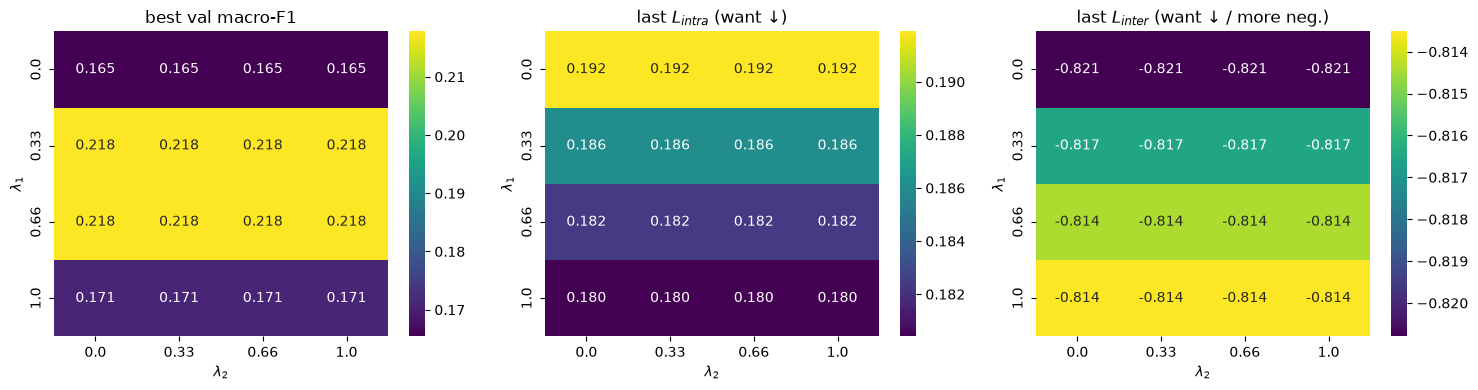

In [27]:
# plots (heatmap)
pivot_f1 = sensitivity_df.pivot(index="lambda1", columns="lambda2", values="val_macro_f1_best")
pivot_intra = sensitivity_df.pivot(index="lambda1", columns="lambda2", values="l_intra_last")
pivot_inter = sensitivity_df.pivot(index="lambda1", columns="lambda2", values="l_inter_last")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, piv, title in [
    (axes[0], pivot_f1, r"best val macro-F1"),
    (axes[1], pivot_intra, r"last $L_{intra}$ (want ↓)"),
    (axes[2], pivot_inter, r"last $L_{inter}$ (want ↓ / more neg.)"),
]:

    sns.heatmap(piv, ax=ax, annot=True, fmt=".3f", cmap="viridis")
    ax.set_xlabel(r"$\lambda_2$")
    ax.set_ylabel(r"$\lambda_1$")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Logging

In [28]:
# write log (final)
log_path = write_history_log(
    {"sensitivity": sensitivity_rows},
    notebook=f"{NOTEBOOK_NAME}.ipynb",
    extra={
        "dataset": dataset,
        "data_path": data_path,
        "split_prefix": split_prefix,
        "seed": seed,
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "n_train": int(len(X_train)),
        "n_val": int(len(X_val)),
        "num_qubits": num_qubits,
        "num_layers": num_layers,
        "noise_rate": noise_rate,
        "barren_plateau_var": barren_plateau_var,
        "lambda1_grid": lambda1_grid,
        "lambda2_grid": lambda2_grid,
        "best_row": sensitivity_df.iloc[0].to_dict(),
        "class_names": list(class_names),
    },
    log_dir="logs",
)
csv_path = Path("logs") / f"{NOTEBOOK_NAME}-sensitivity.csv"
sensitivity_df.to_csv(csv_path, index=False)
print(log_path.resolve())
print(csv_path.resolve())

/home/lawun330/Desktop/quantum-sentinel/logs/tune-lambdas-ciciot2023.log
/home/lawun330/Desktop/quantum-sentinel/logs/tune-lambdas-ciciot2023-sensitivity.csv
